In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.plotting import figure
from bokeh.io import show, output_notebook
import numpy as np
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
output_notebook()

Loading BokehJS ...

## Why Binning Helps Naive Bayes

Naive Bayes estimates class probabilities from feature occurrence counts. For continuous variables, using raw numeric values can create many unique tokens (for example, `age_RAW_37`, `age_RAW_38`, `age_RAW_39`) that each appear infrequently. With a small `max_features` budget, those sparse tokens compete for limited vocabulary space and can crowd out stronger signals.

Binning replaces nearby numeric values with broader categories (for example, `age_BIN_35_44`). This gives each feature more statistical support because more samples fall into the same bin. In practice, this usually makes probability estimates more stable, reduces sparsity, and helps the model prioritize informative patterns when only a small number of features is retained.

In [65]:
import importlib
import adult_preprocessing

importlib.reload(adult_preprocessing)
AdultIncomePreprocessor = adult_preprocessing.AdultIncomePreprocessor
AdultPreprocessConfig = adult_preprocessing.AdultPreprocessConfig

config = AdultPreprocessConfig(
    data_path="census+income/adult.data",
    continuous_mode="binned",  # choose: "raw", "binned", or "both"
)
preprocessor = AdultIncomePreprocessor(config)

demographics, income = preprocessor.load()

print(f"Loaded {len(demographics)} rows from {config.data_path}")
print(f"Positive income count: {sum(income)}")
print(f"Continuous feature mode: {config.continuous_mode}")

print("\nBin frequency summary:")
for line in preprocessor.format_bin_frequency_summary():
    print(line)

Loaded 32561 rows from census+income/adult.data
Positive income count: 7841
Continuous feature mode: binned

Bin frequency summary:
age bin frequencies (n=32561):
         25_34:   8479 (26.04%)
         35_44:   8151 (25.03%)
         45_54:   5853 (17.98%)
          lt25:   5570 (17.11%)
         55_64:   3172 ( 9.74%)
       65_plus:   1336 ( 4.10%)
capital_gain bin frequencies (n=32561):
          zero:  29849 (91.67%)
        1_4999:   1064 ( 3.27%)
     5000_9999:    878 ( 2.70%)
    10000_plus:    770 ( 2.36%)
capital_loss bin frequencies (n=32561):
          zero:  31042 (95.33%)
     1000_1999:   1158 ( 3.56%)
     2000_plus:    325 ( 1.00%)
         1_999:     36 ( 0.11%)
education_num bin frequencies (n=32561):
           mid:  20241 (62.16%)
          high:   7078 (21.74%)
           low:   4253 (13.06%)
     very_high:    989 ( 3.04%)
hours_per_week bin frequencies (n=32561):
         35_44:  18015 (55.33%)
         45_50:   5320 (16.34%)
         20_34:   3879 (11.91%)
  

In [66]:
train_demographics, test_demographics, train_income, test_income = train_test_split(demographics, income, random_state=11)
print('Length of train_demographics is ', len(train_demographics))
print('Length of test_demographics is ',len(test_demographics))

Length of train_demographics is  24420
Length of test_demographics is  8141


mode,max_features,both,raw
0,25,0.762314,0.731974
1,50,0.790566,0.762683
2,75,0.800025,0.770176
3,100,0.808009,0.781231
4,150,0.812185,0.794865
5,200,0.815379,0.799410
6,300,0.821521,0.807640
7,500,0.824223,0.810097
8,800,0.824346,0.810097
9,1000,0.824346,0.810097


mode,max_features,accuracy_diff_both_minus_raw
0,25,0.030340
1,50,0.027884
2,75,0.029849
3,100,0.026778
4,150,0.017320
5,200,0.015969
6,300,0.013880
7,500,0.014126
8,800,0.014249
9,1000,0.014249


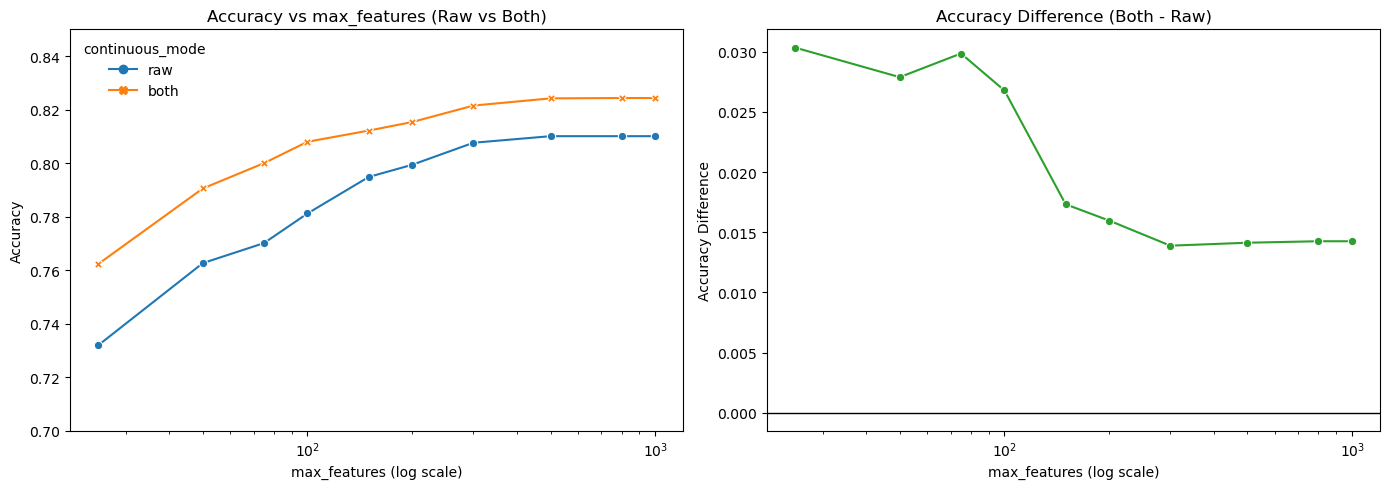

In [67]:
# Compare Naive Bayes accuracy for raw vs both continuous features across max_features.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

feature_grid = [25, 50, 75, 100, 150, 200, 300, 500, 800, 1000]
modes = ["raw", "both"]
results = []

for mode in modes:
    mode_config = AdultPreprocessConfig(
        data_path="census+income/adult.data",
        continuous_mode=mode,
    )
    mode_preprocessor = AdultIncomePreprocessor(mode_config)
    mode_demographics, mode_income = mode_preprocessor.load()

    X_train_mode, X_test_mode, y_train_mode, y_test_mode = train_test_split(
        mode_demographics,
        mode_income,
        random_state=11
    )

    for max_feat in feature_grid:
        vec = CountVectorizer(max_features=max_feat, binary=True, stop_words="english")
        X_train_loop = vec.fit_transform(X_train_mode)
        X_test_loop = vec.transform(X_test_mode)

        model = BernoulliNB()
        model.fit(X_train_loop, y_train_mode)
        y_pred_loop = model.predict(X_test_loop)

        results.append({
            "max_features": max_feat,
            "mode": mode,
            "accuracy": accuracy_score(y_test_mode, y_pred_loop)
        })

perf_df = pd.DataFrame(results)
display(perf_df.pivot(index="max_features", columns="mode", values="accuracy").reset_index())

# Compute and display the accuracy difference: both - raw.
diff_df = perf_df.pivot(index="max_features", columns="mode", values="accuracy").reset_index()
diff_df["accuracy_diff_both_minus_raw"] = diff_df["both"] - diff_df["raw"]
display(diff_df[["max_features", "accuracy_diff_both_minus_raw"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=perf_df,
    x="max_features",
    y="accuracy",
    hue="mode",
    style="mode",
    markers=True,
    dashes=False,
    ax=axes[0]
    )
axes[0].set_xscale("log")
axes[0].set_ylim(0.7, 0.85)
axes[0].set_title("Accuracy vs max_features (Raw vs Both)")
axes[0].set_xlabel("max_features (log scale)")
axes[0].set_ylabel("Accuracy")
axes[0].legend(title="continuous_mode", frameon=False)

sns.lineplot(
    data=diff_df,
    x="max_features",
    y="accuracy_diff_both_minus_raw",
    marker="o",
    color="#2ca02c",
    ax=axes[1]
    )
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xscale("log")
axes[1].set_title("Accuracy Difference (Both - Raw)")
axes[1].set_xlabel("max_features (log scale)")
axes[1].set_ylabel("Accuracy Difference")

plt.tight_layout()
plt.show()

In [106]:
vectorizer = CountVectorizer(max_features=100)
V = vectorizer.fit(train_demographics)
X = V.transform(train_demographics)
train_y = np.array(train_income)
B = BernoulliNB().fit(X,train_y)

In [107]:
T = V.transform(test_demographics)
y_test = np.array(test_income)

In [108]:
print(vectorizer.get_feature_names_out())
print(V.vocabulary_)
print("Processed row example:", demographics[0])

['age_bin_25_34' 'age_bin_35_44' 'age_bin_45_54' 'age_bin_55_64'
 'age_bin_65_plus' 'age_bin_lt25' 'capital_gain_bin_10000_plus'
 'capital_gain_bin_1_4999' 'capital_gain_bin_5000_9999'
 'capital_gain_bin_zero' 'capital_loss_bin_1000_1999'
 'capital_loss_bin_2000_plus' 'capital_loss_bin_zero' 'education_10th'
 'education_11th' 'education_12th' 'education_1st_4th' 'education_5th_6th'
 'education_7th_8th' 'education_9th' 'education_assoc_acdm'
 'education_assoc_voc' 'education_bachelors' 'education_doctorate'
 'education_hs_grad' 'education_masters' 'education_num_bin_high'
 'education_num_bin_low' 'education_num_bin_mid'
 'education_num_bin_very_high' 'education_preschool'
 'education_prof_school' 'education_some_college'
 'hours_per_week_bin_20_34' 'hours_per_week_bin_35_44'
 'hours_per_week_bin_45_50' 'hours_per_week_bin_gt50'
 'hours_per_week_bin_lt20' 'marital_status_divorced'
 'marital_status_married_civ_spouse'
 'marital_status_married_spouse_absent' 'marital_status_never_married'


In [109]:
y_pred = B.predict(T)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8035867829504975

Confusion matrix:
 [[5008 1243]
 [ 356 1534]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      6251
           1       0.55      0.81      0.66      1890

    accuracy                           0.80      8141
   macro avg       0.74      0.81      0.76      8141
weighted avg       0.85      0.80      0.81      8141



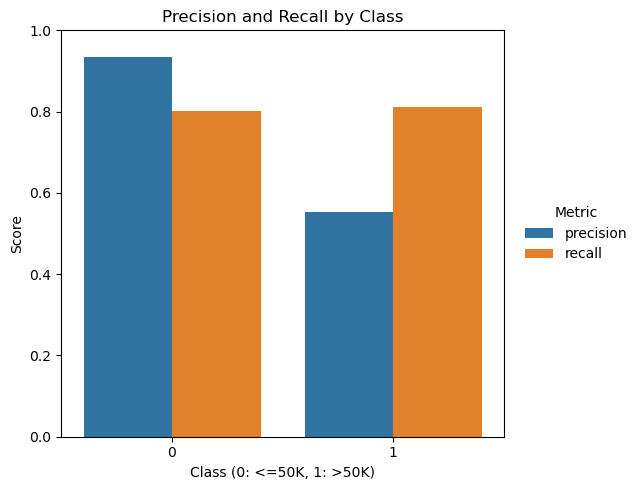

,class,precision,recall
0,0,0.933632,0.801152
1,1,0.552395,0.811640


In [110]:
# Visualize precision and recall from the classification report.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T

# Keep only class rows (exclude accuracy/macro avg/weighted avg).
class_rows = [str(c) for c in sorted(set(y_test))]
metrics_df = report_df.loc[class_rows, ["precision", "recall"]].reset_index()
metrics_df = metrics_df.rename(columns={"index": "class"})
metrics_long = metrics_df.melt(id_vars="class", var_name="metric", value_name="score")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=metrics_long,
    x="class",
    y="score",
    hue="metric",
    palette=["#1f77b4", "#ff7f0e"],
    ax=ax
    )
ax.set_ylim(0, 1)
ax.set_title("Precision and Recall by Class")
ax.set_xlabel("Class (0: <=50K, 1: >50K)")
ax.set_ylabel("Score")
ax.legend(title="Metric", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

display(metrics_df)

In [111]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Export matrix for cross-model comparison plots.
os.makedirs("exports", exist_ok=True)
nb_cm_path = os.path.join("exports", "naive_bayes_confusion_matrix.csv")
np.savetxt(nb_cm_path, cm, fmt="%d", delimiter=",")
print(f"Saved Naive Bayes confusion matrix to: {nb_cm_path}")

Saved Naive Bayes confusion matrix to: exports\naive_bayes_confusion_matrix.csv


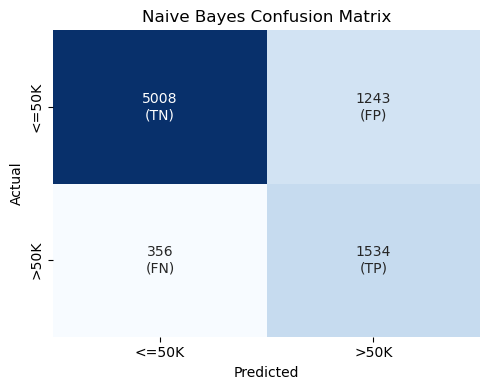

In [112]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cell_labels = np.array([["TN", "FP"], ["FN", "TP"]])
annot_labels = np.array([
    [f"{cm[i, j]}\n({cell_labels[i, j]})" for j in range(2)]
    for i in range(2)
], dtype=object)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

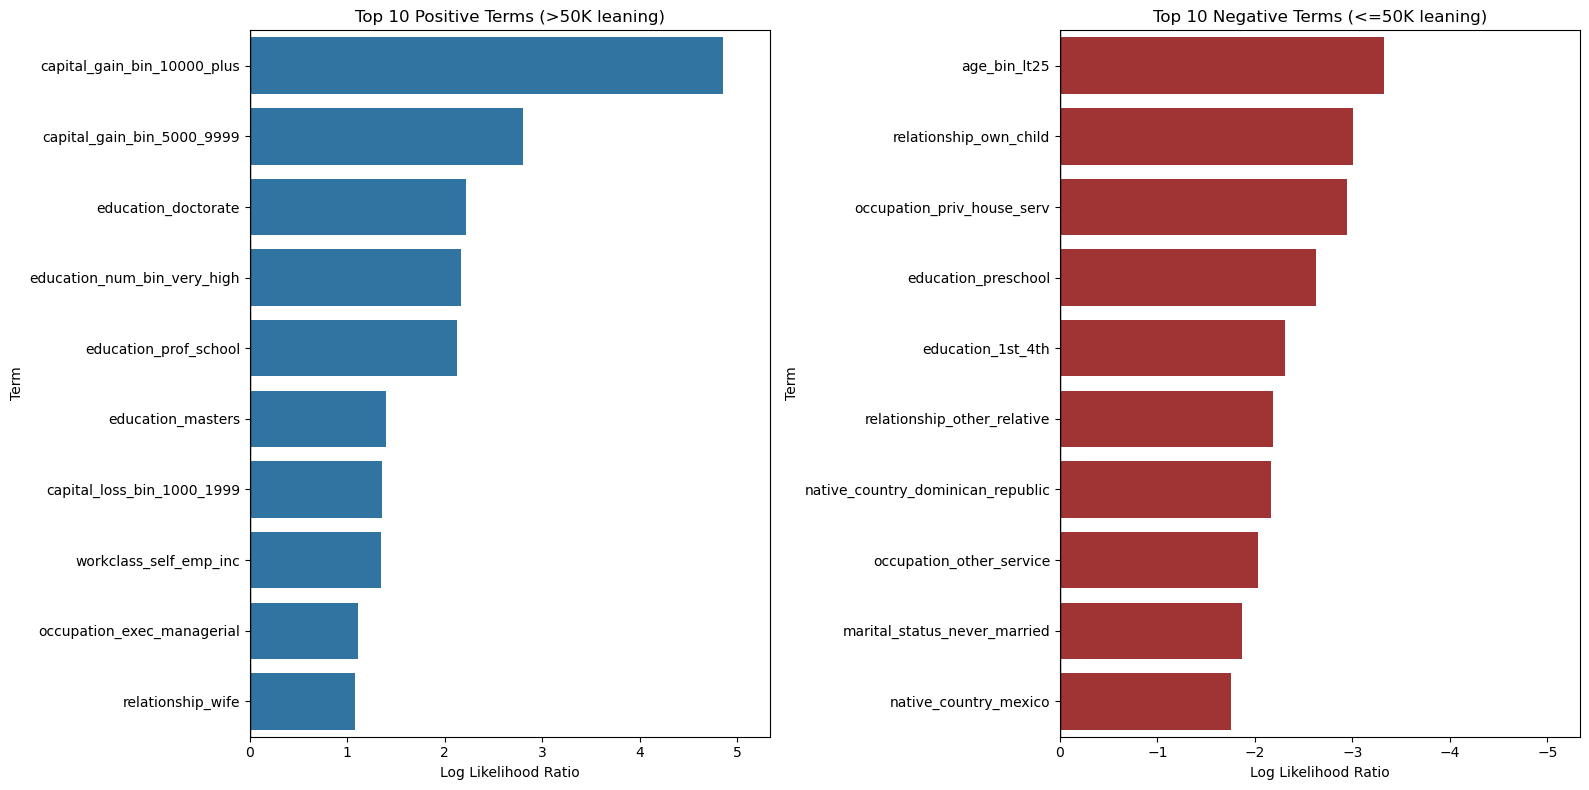

Top 10 positive terms by relative importance (largest absolute value first):


,term,p_term_given_low,p_term_given_high,log_likelihood_ratio
6,capital_gain_bin_10000_plus,0.000758,0.096758,4.849357
8,capital_gain_bin_5000_9999,0.005793,0.095750,2.805114
23,education_doctorate,0.004331,0.039644,2.214112
29,education_num_bin_very_high,0.010665,0.093230,2.168071
31,education_prof_school,0.006388,0.053754,2.129943
25,education_masters,0.031184,0.125483,1.392264
10,capital_loss_bin_1000_1999,0.020789,0.080968,1.359608
96,workclass_self_emp_inc,0.019652,0.075592,1.347151
68,occupation_exec_managerial,0.083645,0.252982,1.106740
90,relationship_wife,0.032916,0.096926,1.079974


Top 10 negative terms by relative importance (largest absolute value first):


,term,p_term_given_low,p_term_given_high,log_likelihood_ratio
5,age_bin_lt25,0.223919,0.008063,-3.323977
88,relationship_own_child,0.201072,0.009911,-3.010021
73,occupation_priv_house_serv,0.006388,0.000336,-2.945231
30,education_preschool,0.002328,0.000168,-2.628893
16,education_1st_4th,0.006767,0.000672,-2.309713
87,relationship_other_relative,0.038980,0.004368,-2.188848
48,native_country_dominican_republic,0.002924,0.000336,-2.163530
72,occupation_other_service,0.127660,0.016798,-2.028092
41,marital_status_never_married,0.413675,0.064001,-1.866178
57,native_country_mexico,0.025283,0.004368,-1.755926


In [114]:
# Relative importance of terms using log likelihood ratio between classes.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = vectorizer.get_feature_names_out()
cond_prob = np.exp(B.feature_log_prob_)

# Class order follows model classes: 0 -> <=50K, 1 -> >50K
p_low = cond_prob[0]
p_high = cond_prob[1]

eps = 1e-12
log_lr = np.log((p_high + eps) / (p_low + eps))

importance_df = pd.DataFrame({
    "term": feature_names,
    "p_term_given_low": p_low,
    "p_term_given_high": p_high,
    "log_likelihood_ratio": log_lr,
    "abs_log_likelihood_ratio": np.abs(log_lr)
})

top_n = 10

# Positive and negative groups, each ordered so largest absolute value appears at the top.
top_terms = importance_df[importance_df["log_likelihood_ratio"] > 0].nlargest(top_n, "log_likelihood_ratio")
top_terms = top_terms.sort_values("abs_log_likelihood_ratio", ascending=False)

bottom_terms = importance_df[importance_df["log_likelihood_ratio"] < 0].nsmallest(top_n, "log_likelihood_ratio")
bottom_terms = bottom_terms.sort_values("abs_log_likelihood_ratio", ascending=False)

# Use the same absolute x-limit on both subplots for direct bar-length comparison.
pos_max = top_terms["log_likelihood_ratio"].max() if len(top_terms) else 0
neg_abs_max = np.abs(bottom_terms["log_likelihood_ratio"].min()) if len(bottom_terms) else 0
shared_abs_limit = max(pos_max, neg_abs_max) * 1.1 if max(pos_max, neg_abs_max) > 0 else 1

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

sns.barplot(
    data=top_terms,
    x="log_likelihood_ratio",
    y="term",
    order=top_terms["term"],
    color="#1f77b4",
    ax=axes[0]
    )
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlim(0, shared_abs_limit)
axes[0].set_title("Top 10 Positive Terms (>50K leaning)")
axes[0].set_xlabel("Log Likelihood Ratio")
axes[0].set_ylabel("Term")

sns.barplot(
    data=bottom_terms,
    x="log_likelihood_ratio",
    y="term",
    order=bottom_terms["term"],
    color="#b22222",
    ax=axes[1]
    )
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlim(0, -shared_abs_limit)
axes[1].set_title("Top 10 Negative Terms (<=50K leaning)")
axes[1].set_xlabel("Log Likelihood Ratio")
axes[1].set_ylabel("Term")

plt.tight_layout()
plt.show()

print("Top 10 positive terms by relative importance (largest absolute value first):")
display(top_terms[[
    "term",
    "p_term_given_low",
    "p_term_given_high",
    "log_likelihood_ratio"
]])

print("Top 10 negative terms by relative importance (largest absolute value first):")
display(bottom_terms[[
    "term",
    "p_term_given_low",
    "p_term_given_high",
    "log_likelihood_ratio"
]])